<a href="https://colab.research.google.com/github/firstsignal/activation-geometry-sentiment/blob/main/ch7_one_clock_many_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 7: one clock, many models — the Phase-Slot Hypothesis meets a stranger

The equation. Everything six chapters found, compressed: for feature f in model m, the detrended concentration wave at fractional depth t ∈ [0, 1] is

w_f(t) = A_f(t) · cos(2πν·t + φ_f)

The content is not the cosine — it is three constraints on its parameters:

	1.	ν is a property of the network, not the feature. One frequency for all features (ch5/ch6: 2.72, 2.73 cycles, shared), constant in fractional depth across layer budgets (ch5: 0.37 at 12, 16, and 24 layers). In Pythia, ν ≈ 2.7.
	2.	φ_f is a property of the feature, not the sentence. A fixed phase address, held pair-by-pair (ch6: R ≥ 0.96), distinct across features (φ_sentiment = 0°, φ_plurality = 21°, φ_tense = 89°; distinctness confirmed, permutation p = 0.005).
	3.	A_f(t) is a gated envelope. Non-negative, time-varying, no growth law (ch5 kill: r² = 0.005). The clock always ticks; the loudness comes and goes.

In [ ]:
!pip -q install transformer-lens
import numpy as np, torch, gc
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from transformer_lens import HookedTransformer

# ============ phaseprobe: the instrument, packaged ============
# Input: a model name + feature specs. Output: nu, phase addresses,
# concentration stats, clock-face figure. Method identical to ch6.

def flip_and_window(tp, tn):
    if tp.shape != tn.shape: return None, None
    d = (tp[0] != tn[0]).nonzero().flatten()
    if len(d) != 1: return None, None
    f = d.item()
    return f, (f + 1, tp.shape[1])

class PhaseProbe:
    def __init__(self, model_name, dtype=torch.float16):
        self.name = model_name
        self.model = HookedTransformer.from_pretrained_no_processing(
            model_name, dtype=dtype)
        self.nL = self.model.cfg.n_layers
        self.x = np.linspace(0, 1, self.nL)

    def _layer_means(self, prompts):
        outs = []
        for p in prompts:
            _, c = self.model.run_with_cache(self.model.to_tokens(p))
            outs.append(torch.stack(
                [c["resid_post", L][0].mean(dim=0).float()
                 for L in range(self.nL)]))
        return torch.stack(outs)

    def build_axes(self, setA, setB):
        A, B = self._layer_means(setA), self._layer_means(setB)
        return {L: (lambda a: a / a.norm())(A[:, L].mean(0) - B[:, L].mean(0))
                for L in range(self.nL)}

    def per_pair_curves(self, axes, pairs, label=""):
        out, used = [], 0
        for s_a, s_b in pairs:
            tpk = self.model.to_tokens(s_a); tnk = self.model.to_tokens(s_b)
            f, win = flip_and_window(tpk, tnk)
            if f is None:
                print(f"  [{label}] skipped (tokenization): {s_a[:40]}")
                continue
            used += 1
            _, cp = self.model.run_with_cache(tpk)
            _, cn = self.model.run_with_cache(tnk)
            curve = []
            for L in range(self.nL):
                dvec = (cp["resid_post", L][0] - cn["resid_post", L][0]).float()
                ax = axes[L]
                on  = (dvec @ ax).abs()[win[0]:win[1]].mean().item()
                off = (dvec - (dvec @ ax)[:, None] * ax[None, :]
                       ).norm(dim=-1)[win[0]:win[1]].mean().item()
                curve.append(on / off)
            out.append(curve); del cp, cn
        print(f"  [{label}] pairs used: {used}/{len(pairs)}")
        return np.array(out)

    def detrend(self, row):
        return row - np.polyval(np.polyfit(self.x, row, 2), self.x)

    def wave_stats(self, P):
        R_ = np.stack([self.detrend(r) for r in P])
        within = np.mean([np.corrcoef(R_[i], R_[j])[0, 1]
                          for i in range(len(R_))
                          for j in range(i + 1, len(R_))])
        w = self.detrend(P.mean(0))
        ph = np.unwrap(np.angle(hilbert(w)))
        cycles = (ph[-1] - ph[0]) / (2 * np.pi)
        return w, within, cycles

    def per_pair_offsets(self, P, w_ref, min_loud=4, thresh=0.35):
        ph_ref = np.unwrap(np.angle(hilbert(w_ref)))
        amp_ref = np.abs(hilbert(w_ref))
        ref_loud = amp_ref > thresh * amp_ref.max()
        offs = []
        for row in P:
            w = self.detrend(row)
            a = hilbert(w)
            ph, amp = np.unwrap(np.angle(a)), np.abs(a)
            loud = ref_loud & (amp > thresh * amp.max())
            if loud.sum() < min_loud: continue
            z = np.mean(np.exp(1j * (ph[loud] - ph_ref[loud])))
            offs.append(np.angle(z))
        return np.array(offs)

    def close(self):
        del self.model; gc.collect(); torch.cuda.empty_cache()

def circ_mean_R(a):
    z = np.mean(np.exp(1j * a))
    return np.angle(z), np.abs(z)

def perm_test_separation(a1, a2, n_perm=10000, seed=0):
    def stat(u, v):
        m1, _ = circ_mean_R(u); m2, _ = circ_mean_R(v)
        return abs(np.angle(np.exp(1j * (m1 - m2))))
    obs = stat(a1, a2)
    pooled = np.concatenate([a1, a2]); n1 = len(a1)
    rng = np.random.default_rng(seed); count = 0
    for _ in range(n_perm):
        p = rng.permutation(pooled)
        if stat(p[:n1], p[n1:]) >= obs: count += 1
    return np.degrees(obs), (count + 1) / (n_perm + 1)

print("phaseprobe loaded")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.0 MB/s eta 0:00:00
phaseprobe loaded


In [ ]:
!pip -q install transformer-lens
import numpy as np, torch, gc
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from transformer_lens import HookedTransformer

# ---- sentiment axis sets (ch4/ch5 recipe) ----
pos_matched = [
    "The meal at the restaurant was absolutely wonderful.",
    "Her performance in the final act was brilliant.",
    "The weather on the coast stayed lovely all week.",
    "His speech at the ceremony sounded inspiring.",
    "The ending of the novel felt satisfying.",
]
neg_matched = [
    "The meal at the restaurant was absolutely terrible.",
    "Her performance in the final act was dreadful.",
    "The weather on the coast stayed miserable all week.",
    "His speech at the ceremony sounded tedious.",
    "The ending of the novel felt hollow.",
]
sent_pairs = [
    ("The concert in the park sounded wonderful and the crowd stayed late.",
     "The concert in the park sounded terrible and the crowd stayed late."),
    ("Her garden looked beautiful after the rain stopped falling.",
     "Her garden looked dreadful after the rain stopped falling."),
    ("The service at the hotel was excellent and the staff seemed calm.",
     "The service at the hotel was awful and the staff seemed calm."),
    ("His first attempt at the recipe tasted delicious and the kitchen smelled good.",
     "His first attempt at the recipe tasted disgusting and the kitchen smelled good."),
    ("The view from the window seemed lovely in the morning light.",
     "The view from the window seemed miserable in the morning light."),
    ("The lecture on physics felt inspiring and the students asked questions.",
     "The lecture on physics felt tedious and the students asked questions."),
    ("The journey through the mountains was pleasant and the roads stayed clear.",
     "The journey through the mountains was horrible and the roads stayed clear."),
    ("The film about the ocean looked stunning and the music matched well.",
     "The film about the ocean looked boring and the music matched well."),
    ("The bread from the bakery smelled amazing and the queue moved quickly.",
     "The bread from the bakery smelled horrid and the queue moved quickly."),
    ("The report on the findings read brilliant and the figures looked clear.",
     "The report on the findings read hopeless and the figures looked clear."),
]

# ---- tense axis sets + test pairs (ch5, verbatim) ----
past_ax = [
    "She walked to the station and caught the early train.",
    "They finished the project and celebrated last night.",
    "He wrote the letter and posted it yesterday morning.",
    "We visited the museum and admired the old paintings.",
    "I cooked dinner and washed the dishes afterwards.",
]
pres_ax = [
    "She walks to the station and catches the early train.",
    "They finish the project and celebrate tonight.",
    "He writes the letter and posts it this morning.",
    "We visit the museum and admire the old paintings.",
    "I cook dinner and wash the dishes afterwards.",
]
tense_pairs = [
    ("The gardener watered the plants and the flowers looked bright.",
     "The gardener waters the plants and the flowers looked bright."),
    ("The children played in the yard and the dog barked loudly.",
     "The children play in the yard and the dog barked loudly."),
    ("The chef cooked the meal and the guests waited patiently.",
     "The chef cooks the meal and the guests waited patiently."),
    ("The student answered the question and the teacher nodded slowly.",
     "The student answers the question and the teacher nodded slowly."),
    ("The painter finished the mural and the crowd gathered outside.",
     "The painter finishes the mural and the crowd gathered outside."),
    ("The driver parked the van and the workers unloaded boxes.",
     "The driver parks the van and the workers unloaded boxes."),
    ("The singer performed the song and the audience clapped warmly.",
     "The singer performs the song and the audience clapped warmly."),
    ("The farmer planted the seeds and the field stretched wide.",
     "The farmer plants the seeds and the field stretched wide."),
    ("The writer typed the chapter and the editor read quietly.",
     "The writer types the chapter and the editor read quietly."),
]

# ---- plurality axis sets (ch2, verbatim) ----
sing_ax = [
    "The dog runs across the field near the river.",
    "A child plays in the garden every afternoon.",
    "The teacher explains the lesson to the class.",
    "The bird sings loudly from the tall tree.",
    "The car waits outside the old station.",
]
plur_ax = [
    "The dogs run across the fields near the rivers.",
    "Children play in the gardens every afternoon.",
    "The teachers explain the lessons to the classes.",
    "The birds sing loudly from the tall trees.",
    "The cars wait outside the old stations.",
]
# plurality TEST pairs — past tense (no agreement), noun-only single-token flip
plural_pairs = [
    ("The dog slept on the warm floor and the house stayed quiet.",
     "The dogs slept on the warm floor and the house stayed quiet."),
    ("The girl walked to the station and the streets looked empty.",
     "The girls walked to the station and the streets looked empty."),
    ("The book fell from the shelf and the noise startled everyone.",
     "The books fell from the shelf and the noise startled everyone."),
    ("The car stopped at the light and the engine kept running.",
     "The cars stopped at the light and the engine kept running."),
    ("The bird landed on the wire and the garden fell silent.",
     "The birds landed on the wire and the garden fell silent."),
    ("The window opened without warning and the papers blew everywhere.",
     "The windows opened without warning and the papers blew everywhere."),
    ("The letter arrived on Monday and the reply came quickly.",
     "The letters arrived on Monday and the reply came quickly."),
    ("The player scored in the final and the crowd cheered loudly.",
     "The players scored in the final and the crowd cheered loudly."),
    ("The key opened the front door and the hallway smelled fresh.",
     "The keys opened the front door and the hallway smelled fresh."),
]

def flip_and_window(tp, tn):
    if tp.shape != tn.shape: return None, None
    d = (tp[0] != tn[0]).nonzero().flatten()
    if len(d) != 1: return None, None
    f = d.item()
    return f, (f + 1, tp.shape[1])

print("cell 1 loaded:", len(sent_pairs), "sentiment,",
      len(tense_pairs), "tense,", len(plural_pairs), "plurality pairs")


cell 1 loaded: 10 sentiment, 9 tense, 9 plurality pairs


Weights fetched via curl and loaded from local disk (HF Hub client downloads were stalling on the day of this run — see ch6 for detail).

In [ ]:
!curl -L --fail --progress-bar -o /content/gpt2/model.safetensors "https://huggingface.co/openai-community/gpt2/resolve/main/model.safetensors"
!ls -la /content/gpt2


######################################################################## 100.0%
total 538072
drwxr-xr-x 2 root root      4096 Jul 14 16:16 .
drwxr-xr-x 1 root root      4096 Jul 14 16:13 ..
-rw-r--r-- 1 root root       665 Jul 14 16:13 config.json
-rw-r--r-- 1 root root    456318 Jul 14 16:13 merges.txt
-rw-r--r-- 1 root root 548105171 Jul 14 16:16 model.safetensors
-rw-r--r-- 1 root root        26 Jul 14 16:13 tokenizer_config.json
-rw-r--r-- 1 root root   1355256 Jul 14 16:13 tokenizer.json
-rw-r--r-- 1 root root   1042301 Jul 14 16:13 vocab.json


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
hf_model = AutoModelForCausalLM.from_pretrained("/content/gpt2", torch_dtype=torch.float32)
tok = AutoTokenizer.from_pretrained("/content/gpt2")
probe = PhaseProbe.__new__(PhaseProbe)
probe.name = "gpt2"
probe.model = HookedTransformer.from_pretrained_no_processing(
    "gpt2", hf_model=hf_model, tokenizer=tok, dtype=torch.float32)
probe.nL = probe.model.cfg.n_layers
probe.x = np.linspace(0, 1, probe.nL)
print(f"{probe.name}: {probe.nL} layers")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
gpt2: 12 layers


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
gpt2: 12 layers

  [sentiment] skipped (tokenization): The bread from the bakery smelled amazin
  [sentiment] pairs used: 9/10
  [tense] pairs used: 9/9
  [plurality] pairs used: 9/9

SENTIMENT: alignment 0.877 | cycles 1.60   <- P1/P2
TENSE    : alignment -0.032 | cycles 2.56
PLURALITY: alignment 0.157 | cycles 2.40
  control: n=9 | mean +1.2° | R = 0.97
    tense: n=9 | mean -140.5° | R = 0.17
plurality: n=9 | mean -87.9° | R = 0.11

P3 verdict — tense vs control: separation 141.7°, permutation p = 0.0140


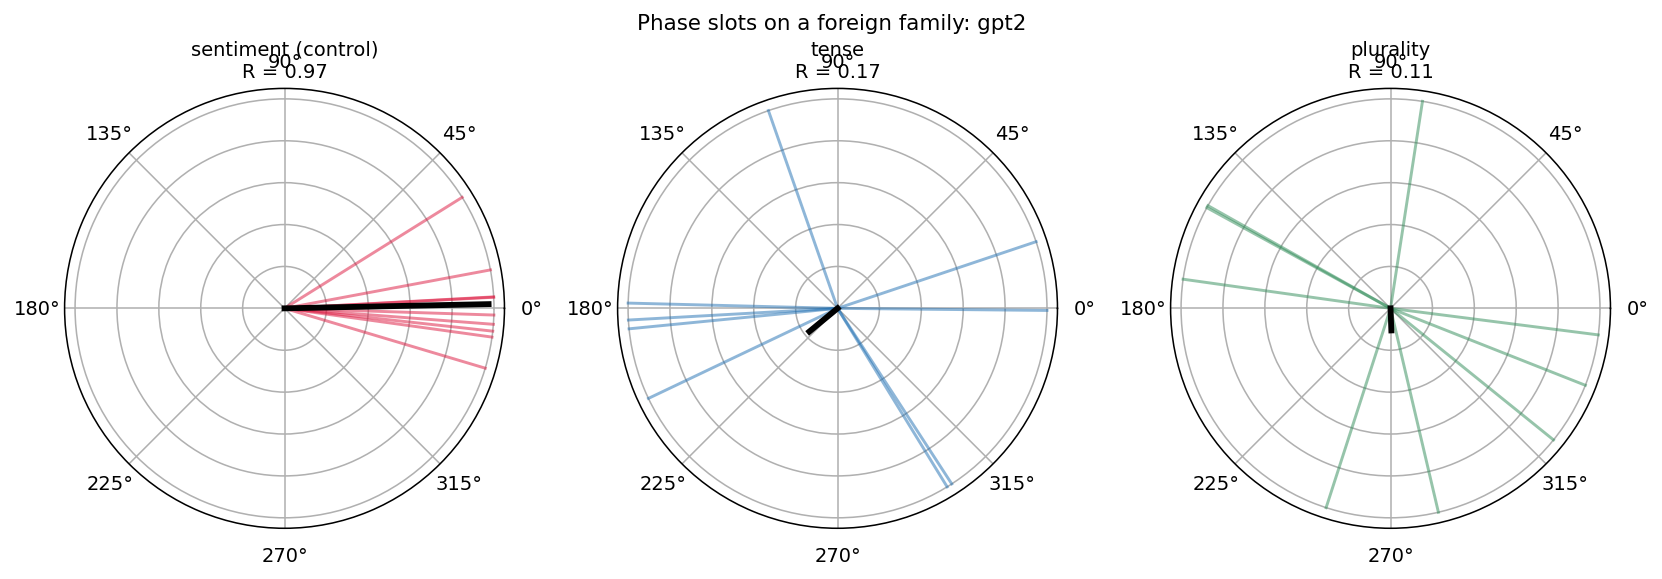

In [ ]:
probe = PhaseProbe("gpt2")   # GPT-2 small, 12 layers
print(f"{probe.name}: {probe.nL} layers\n")

sent_axes  = probe.build_axes(pos_matched, neg_matched)
tense_axes = probe.build_axes(past_ax, pres_ax)
plur_axes  = probe.build_axes(plur_ax, sing_ax)

P_s = probe.per_pair_curves(sent_axes,  sent_pairs,   "sentiment")
P_t = probe.per_pair_curves(tense_axes, tense_pairs,  "tense")
P_p = probe.per_pair_curves(plur_axes,  plural_pairs, "plurality")

w_s, al_s, cy_s = probe.wave_stats(P_s)
w_t, al_t, cy_t = probe.wave_stats(P_t)
w_p, al_p, cy_p = probe.wave_stats(P_p)
print(f"\nSENTIMENT: alignment {al_s:.3f} | cycles {cy_s:.2f}   <- P1/P2")
print(f"TENSE    : alignment {al_t:.3f} | cycles {cy_t:.2f}")
print(f"PLURALITY: alignment {al_p:.3f} | cycles {cy_p:.2f}")

offs_ctrl = probe.per_pair_offsets(P_s, w_s)
offs_t    = probe.per_pair_offsets(P_t, w_s)
offs_p    = probe.per_pair_offsets(P_p, w_s)
for nm, o in [("control", offs_ctrl), ("tense", offs_t), ("plurality", offs_p)]:
    if len(o):
        mu, R = circ_mean_R(o)
        print(f"{nm:>9}: n={len(o)} | mean {np.degrees(mu):+.1f}° | R = {R:.2f}")
    else:
        print(f"{nm:>9}: no pairs survive joint-loudness — underpowered")

if len(offs_t) >= 4:
    sep, p = perm_test_separation(offs_ctrl, offs_t)
    print(f"\nP3 verdict — tense vs control: separation {sep:.1f}°, "
          f"permutation p = {p:.4f}")
else:
    print("\nP3: not resolvable (tense n < 4)")

fig, ax_ = plt.subplots(1, 3, figsize=(12, 4), dpi=140,
                        subplot_kw={'projection': 'polar'})
for a, (offs, label, col) in zip(ax_, [
        (offs_ctrl, "sentiment (control)", '#dc143c'),
        (offs_t, "tense", '#1f6fb2'),
        (offs_p, "plurality", '#2e8b57')]):
    if len(offs):
        mu, R = circ_mean_R(offs)
        for o in offs: a.plot([o, o], [0, 1], '-', color=col, alpha=0.5, lw=1.5)
        a.plot([mu, mu], [0, R], '-', color='black', lw=3)
        a.set_title(f"{label}\nR = {R:.2f}", fontsize=10)
    else:
        a.set_title(f"{label}\n(underpowered)", fontsize=10)
    a.set_yticklabels([])
plt.suptitle(f"Phase slots on a foreign family: {probe.name}", fontsize=11)
plt.tight_layout()
plt.savefig("phase_slots_gpt2.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()

probe.close()

P2 (period in-band, 2.7 ± 0.4 fractional cycles): killed — and the kill is the finding. GPT-2 completes 1.60 cycles across depth. This is not noise: the self-control clusters at R = 0.97, so the wave is coherent — it simply ticks at a different rate. The pre-named sub-outcome lands: family-specific clock, universal clock-structure. Constraint 1 of the Phase-Slot Hypothesis is scoped by data: ν is a per-network constant, not a constant of transformers.

**P3 (tense slots distinctly; both per-pair R > 0.7, permutation< 0.05): gated — no verdict. Tense per-pair R = 0.17, plurality 0.11: both fail the pre-registered R gate decisively. The permutation test printed p = 0.014, and it is disregarded per the locked gate — a mean angle computed on near-uniform scatter is not a slot address, and a significance test on it is not evidence of one. Slot structure in GPT-2 is unresolved, not absent.

Three suspects for the tense/plurality collapse, in order: (1) instrument starvation — 1.6 cycles over 12 layers gives per-pair Hilbert phase far less signal than 2.7 over 24; (2) Pythia-tuned axes — the tense and plurality sentence sets were built and validated on Pythia’s representations, and the same difference-of-means recipe may catch GPT-2’s encoding of those features poorly (sentiment, the strongest and most lexical axis, survives regardless); (3) GPT-2 genuinely does not slot grammatical features — admissible only after (1) and (2) are killed.

Standing verdict: the wave replicates across families and strengthens; the clock rate does not transfer — periods are family-specific; the slot structure is unresolved in GPT-2, gated by instrument power. One survival, one instructive kill, one gate — the house pattern, on a foreign model, first try.

Queued: GPT-2-medium (24 layers — matches 410m’s layer count, tests suspect 1 directly, pre-register fresh before running); GPT-2-native axis-building sets (tests suspect 2); cross-family ν survey (does each family hold one stable ν of its own?).